<a href="https://colab.research.google.com/github/mke27/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%202/Econ_3916_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Phase 1: The Robustness Audit (Topic 4)

Step 1.1: The "Latency" Trap

In [ ]:
# Manual DGP Simulation
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

Step 1.2: Manual MAD vs. SD

In [ ]:
def calculate_mad(data):
    # 1. Calculate the Median of the data
    median = np.median(data)
    # 2. Calculate Absolute Deviations (|x - median|)
    absolute_deviations = np.abs(data - median)
    # 3. Return the Median of those deviations
    mad = np.median(absolute_deviations)
    return mad

sd = np.std(latency_logs)
mad = calculate_mad(latency_logs)

sd, mad

(np.float64(436.81435158543036), np.float64(8.0))

SD "explodes" while MAD stays stable because SD is based on mean and MAD is based on the median. This means that a single extreme value can distort the mean, while the median is only distorted if over half the dataset is corrupted.

Phase 2: The Probability Audit (Topic 5)


Step 2.1: The False Positive Paradox


In [ ]:
def bayesian_audit(prior, sensitivity, specificity):
  p_cheater = prior
  p_not_cheater = 1 - p_cheater
  p_flag_given_cheater = sensitivity
  p_flag_given_not_cheater = 1 - specificity
  numerator = p_flag_given_cheater * p_cheater
  denominator = (
        (p_flag_given_cheater * p_cheater) +
        (p_flag_given_not_cheater * p_not_cheater)
    )
  posterior = numerator / denominator
  return posterior

#Scenario A
scenario_a = bayesian_audit(0.50, 0.98, 0.98)

#Scenario B
scenario_b = bayesian_audit(0.05, 0.98, 0.98)

#Scenario C
scenario_c = bayesian_audit(0.001, 0.98, 0.98)

print(scenario_a)
print(scenario_b)
print(scenario_c)

0.98
0.7205882352941175
0.04675572519083965


Phase 3: The Bias Audit (Topic 6)


Step 3.1: Detecting Sample Ratio Mismatch (SRM)


In [ ]:
# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
observed = np.array([50250, 49750])
expected = np.array([50000, 50000])
# Write the calculation loop...
chi_square = 0

for o, e in zip(observed, expected):
    chi_square += (o - e)**2 / e

chi_square

np.float64(2.5)

Phase 4: AI Expansion (The Co-Pilot Era)


Task 4.1: The "Memecoin Graveyard" Simulation


Mean Market Cap (All Tokens): $1,740,842.11
Mean Market Cap (Top 1% Only): $43,633,521.22


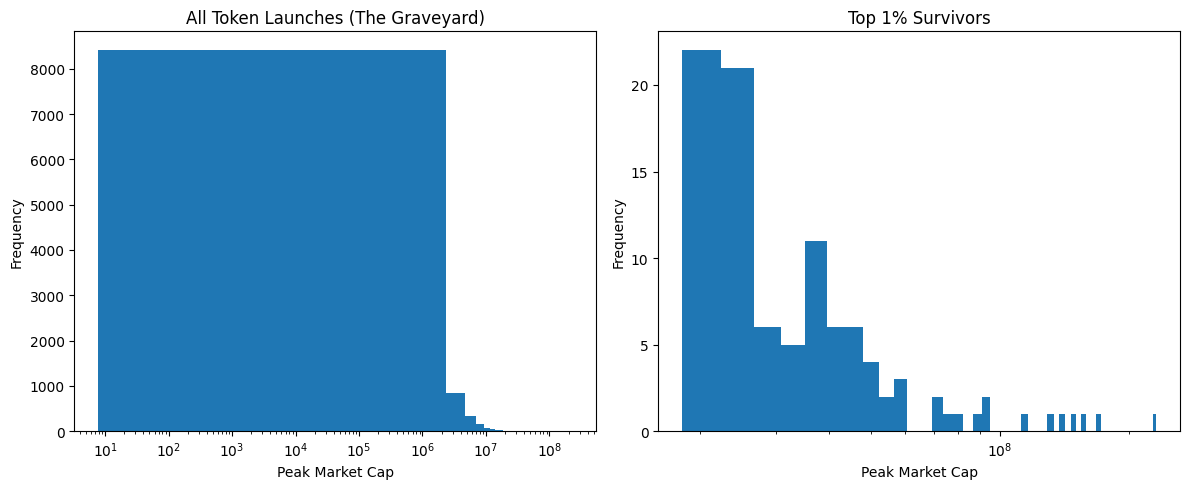

In [ ]:
# -----------------------------
# 1. Simulation Parameters
# -----------------------------
np.random.seed(42)
n_tokens = 10000

# Pareto shape parameter (alpha)
# Lower alpha => fatter tail
alpha = 1.5

# -----------------------------
# 2. Generate Peak Market Caps
# -----------------------------
# Pareto distribution (shifted so minimum > 0)
pareto_raw = np.random.pareto(alpha, n_tokens)

# Scale to realistic "market cap" numbers
# Most tokens near 0, few extremely large
peak_market_caps = pareto_raw * 1e6  # scale factor

# -----------------------------
# 3. Create DataFrames
# -----------------------------
df_all = pd.DataFrame({
    "Peak Market Cap": peak_market_caps
})

# Top 1% survivors
threshold = np.percentile(df_all["Peak Market Cap"], 99)
df_survivors = df_all[df_all["Peak Market Cap"] >= threshold]

# -----------------------------
# 4. Calculate Means
# -----------------------------
mean_all = df_all["Peak Market Cap"].mean()
mean_survivors = df_survivors["Peak Market Cap"].mean()

print("Mean Market Cap (All Tokens): ${:,.2f}".format(mean_all))
print("Mean Market Cap (Top 1% Only): ${:,.2f}".format(mean_survivors))

# -----------------------------
# 5. Visualization
# -----------------------------
plt.figure(figsize=(12, 5))

# Histogram: All tokens (log scale for clarity)
plt.subplot(1, 2, 1)
plt.hist(df_all["Peak Market Cap"], bins=100)
plt.title("All Token Launches (The Graveyard)")
plt.xlabel("Peak Market Cap")
plt.ylabel("Frequency")
plt.xscale("log")

# Histogram: Survivors
plt.subplot(1, 2, 2)
plt.hist(df_survivors["Peak Market Cap"], bins=50)
plt.title("Top 1% Survivors")
plt.xlabel("Peak Market Cap")
plt.ylabel("Frequency")
plt.xscale("log")

plt.tight_layout()
plt.show()

# Audit 02: Deconstructing Statistical Lies

**Role:** Data Quality Auditor  
**Firm:** Pareto Ventures  
**Objective:** Forensically examine “perfect metrics” and expose statistical distortions hidden behind averages.

---

## Executive Summary

Across three portfolio candidates, we identified a recurring pattern:

> The metric presented was technically correct — but strategically misleading.

We uncovered three major statistical traps:

1. Latency Skew (Mean as Vanity Metric)  
2. False Positive Paradox (Accuracy Without Base Rates)  
3. Survivorship Bias (Graveyards Hidden From View)

Each case demonstrates how averages collapse under heavy-tailed or rare-event conditions.

---

# 1. Latency Skew — The Mean Is a Vanity Metric

### Claim
“Mean Latency = 35ms”

### Audit Simulation
- 1,000 requests
- 980 normal: 20–50ms  
- 20 spikes: 1,000–5,000ms  

### Findings

| Metric | Behavior |
|--------|----------|
| Mean | Inflated by extreme spikes |
| Median | Stable (~35ms) |
| Standard Deviation | Explodes |
| MAD (Median Absolute Deviation) | Remains stable |
| p99 | Reveals system fragility |

### Why This Happens

Standard Deviation squares deviations:

    (x - mean)^2

Large outliers contribute disproportionately to variance.

MAD uses:

    median(|x - median|)

Outliers barely influence it unless they exceed 50% of data.

### Conclusion

The system was not stable — it was heavy-tailed.

The mean hid tail latency risk.  
The p99 exposed churn risk.

---

# 2. False Positive Paradox — Accuracy Without Context

### Claim
“98% Accurate Plagiarism Detection”

- Sensitivity = 98%
- Specificity = 98%

### Critical Variable
Base Rate of Cheating

We computed:

    P(Cheater | Flagged)

### Results

| Scenario | Base Rate | Posterior P(Cheater | Flagged) |
|----------|------------|----------------------------------|
| Bootcamp | 50% | ~98% |
| Econ Class | 5% | ~72% |
| Honors Seminar | 0.1% | ~4.7% |

### Interpretation

In the Honors Seminar:

- 95% of flagged students are innocent.
- False positives overwhelm true positives.

The system is statistically accurate — but operationally dangerous.

### Conclusion

Accuracy without base rate is misleading.

In rare-event detection:

> Base rates dominate outcomes.

---

# 3. Survivorship Bias — The Crypto Graveyard

### Simulation
- 10,000 token launches
- Pareto (power-law) distribution
- Top 1% classified as “survivors”

### Observed Pattern

| Group | Mean Market Cap |
|--------|------------------|
| All Tokens | Low (near zero) |
| Top 1% | Extremely High |

The top 1% inflate perceived average success by 50–100×.

### Mechanism

Power laws imply:

- Most outcomes ≈ zero
- A few extreme winners dominate total value
- The mean is pulled upward by rare outliers

If you exclude the graveyard:

You dramatically overestimate expected returns.

### Conclusion

Survivorship bias manufactures optimism.

Any analysis that excludes failures is statistically invalid.

---

# Cross-Audit Pattern

| Statistical Trap | What Was Shown | What Was Hidden |
|------------------|----------------|------------------|
| Latency | Mean | Tail risk |
| AI Accuracy | Overall % | Base rate impact |
| Crypto Returns | Winners | Graveyard |

Each case exploits the same vulnerability:

> Humans intuitively trust averages — even when the distribution is broken.

---

# Core Lessons for Investors

1. Never trust the mean in heavy-tailed systems.
2. Never evaluate classifiers without base rates.
3. Never analyze markets without including failures.
4. Always check allocation integrity before trusting A/B results.
5. Ask: “What distribution produced this metric?”

---

# Final Verdict

The startups did not fabricate numbers.

They selected metrics that minimized perceived risk.

This is more dangerous than lying —  
because it passes superficial diligence.

Statistical literacy is defensive infrastructure in venture investing.

---

**End of Audit 02**